In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sys import path
import os
root = Path("").resolve().parent.parent.parent
os.chdir(root)
from lib.funs import elliptic_hess_for_dim

In [2]:
DIM = 10
DATA_PATH = f"/home/maksym/studia/praca-inzynierska/thesis-2/experiments/experimentum_crucis/results/elliptic_d{DIM}/elliptic_d{DIM}.parquet"
df = pd.read_parquet(DATA_PATH)
df

,best,cov_mat_eigv,sigma,run_id
num_evaluations,,,,
40,1.676550e+09,"[0.8384632386798597, 0.8649838901542111, 0.886...",1.330753,1
80,1.529469e+09,"[0.7699118368757263, 0.8191078089683668, 0.848...",2.075507,1
120,1.401669e+09,"[0.7111139398959417, 0.7524329653779822, 0.807...",3.241432,1
160,1.127097e+09,"[0.6775162532315601, 0.708537923552768, 0.7695...",5.300383,1
200,8.038809e+08,"[0.6243069682071781, 0.692689726415757, 0.7585...",8.583382,1
...,...,...,...,...
8160,1.449856e-10,"[3.1809029927425375e-09, 1.779781697201489e-08...",0.000158,25
8200,1.449856e-10,"[2.7775736052608706e-09, 1.735280947039577e-08...",0.000127,25
8240,1.449856e-10,"[2.61455513498356e-09, 1.512572547676092e-08, ...",0.000113,25


In [3]:
averaged = df.drop(columns=["run_id"]).groupby(level=0).mean()
ndim = len(averaged.iloc[0]["cov_mat_eigv"])
eig_as_arr = np.array(list(averaged["cov_mat_eigv"]))
print(ndim)
# eig_as_arr

10


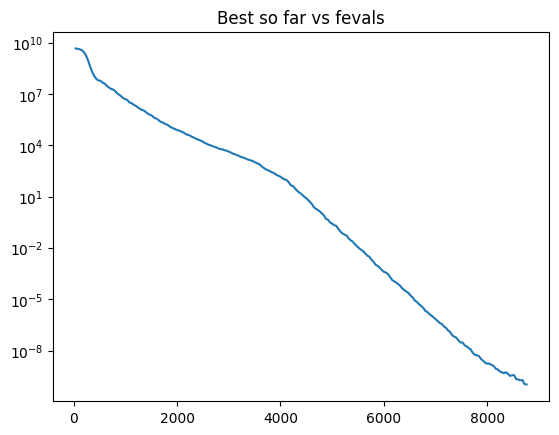

In [4]:
plt.semilogy(averaged.index, averaged["best"])
plt.title("Best so far vs fevals")
plt.show()

In [22]:
for i in range(ndim):
    plt.semilogy(averaged.index, eig_as_arr[:, i])
plt.title("Raw eigenvalue plot")
plt.show()

KeyError: 'key of type tuple not found and not a MultiIndex'

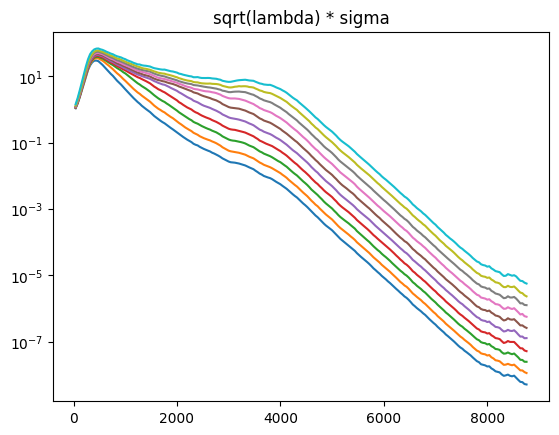

In [6]:
for i in range(ndim):
    plt.semilogy(averaged.index, np.sqrt(eig_as_arr[:, i]) * averaged["sigma"])
plt.title("sqrt(lambda) * sigma")
plt.show()

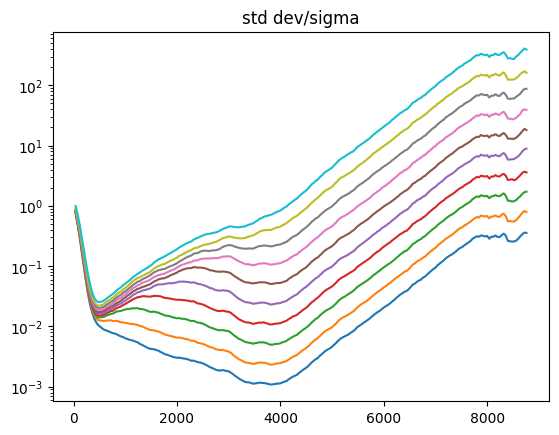

In [7]:
for i in range(ndim):
    plt.semilogy(averaged.index, np.sqrt(eig_as_arr[:, i]) / averaged["sigma"])
plt.title("std dev/sigma")
plt.show()

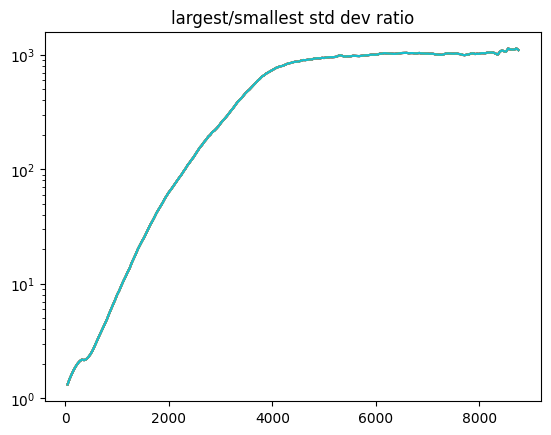

In [8]:
for i in range(ndim):
    plt.semilogy(averaged.index, np.sqrt(eig_as_arr[:, ndim-1] /  eig_as_arr[:, 0]))
plt.title("largest/smallest std dev ratio")
plt.show()

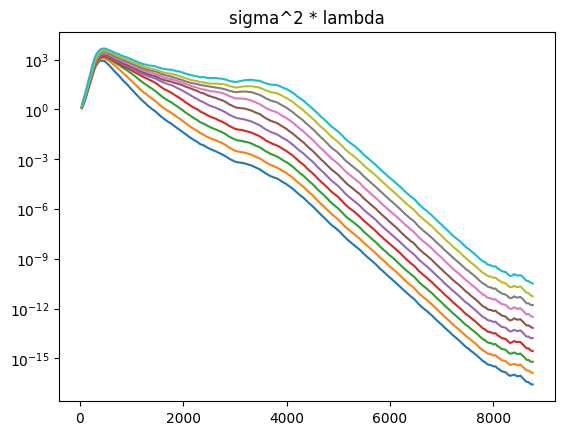

In [9]:
for i in range(ndim):
    plt.semilogy(averaged.index, eig_as_arr[:, i] * averaged["sigma"]**2)

plt.title("sigma^2 * lambda")
plt.show()

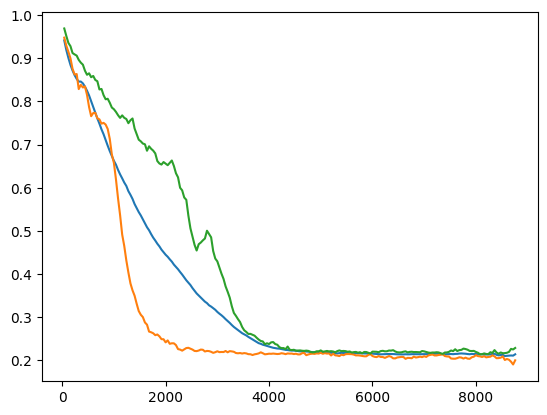

In [21]:
eig_ratios = np.divide(eig_as_arr[:,:-1], eig_as_arr[:, 1:])
eig_avg = np.average(eig_ratios, axis=1)
quantiles = np.quantile(eig_ratios, [0.25, 0.75], axis=1)


plt.plot(averaged.index, eig_avg)
plt.plot(averaged.index, quantiles[0])
plt.plot(averaged.index, quantiles[1])